# DAGonStar Tutorial Notebook

This notebook runs 15 runnable lessons in the order the slide deck
(`DAGonStar_tutorial_slides.md`) presents them. Each section has a short
explanation plus the lesson's actual code, adapted to run as notebook cells
instead of standalone scripts.

**Requirements:**
- Open this notebook from the repository root (the same directory that contains `tutorial/`).
- Python 3.8+.
- Lesson 10 (Docker-Backed Task) needs a working Docker daemon on this machine.
- Lesson 11 (Remote Batch Task over SSH) needs a reachable SSH host and an
  authorized key -- see `tutorial/README.md` for the one-time setup.

Notebook lesson numbers are sequential in presentation order and do not
always match the `tutorial/lesson_NN_*.py` filenames -- see
`tutorial/README.md` for the exact mapping.

Slurm-backed tasks (covered conceptually in the slides' Section 6) need
infrastructure this notebook does not set up, so they are not included here.


## Setup


In [1]:
import sys
!{sys.executable} -m pip install -q "dagonstar[docker] @ git+https://github.com/DagOnStar/dagonstar.git"


In [2]:
import sys
from pathlib import Path

# This notebook expects to be opened from the repository root, next to `tutorial/`.
REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "tutorial").is_dir(), (
    "Could not find the `tutorial/` folder next to this notebook. "
    "Open this notebook from the repository root (dagonstartutorial/)."
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import dagon
print("dagon package OK:", dagon.Workflow.__name__)


dagon package OK: Workflow


In [3]:
import json
import os
import shutil
import tempfile
import threading
import time
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path

from dagon import DataMover, Workflow
from dagon.fair import Agent, Artifact, FairProfile
from dagon.task import DagonTask, TaskType

from tutorial.common.meteorological_data import CSV
from tutorial.common.support import observation_command, require_text, workflow


A small helper to draw the actual graph of a `Workflow` object after it has been built, straight from its live `tasks`/`prevs`/`nexts` state -- not a hand-drawn picture that could drift from the code. It only appears after lessons where the graph shape itself is worth seeing (more than one task, or a fan-out/fan-in/cycle worth looking at).


In [4]:
from IPython.display import display
import graphviz


def draw_workflow(wf, title=None):
    dot = graphviz.Digraph()
    dot.graph_attr.update(rankdir="LR", bgcolor="transparent")
    if title:
        dot.graph_attr.update(
            label=title, fontsize="14", labelloc="t", fontname="DejaVu Sans"
        )
    dot.node_attr.update(
        shape="box", style="rounded,filled", fontname="DejaVu Sans",
        fontsize="12", color="#0b6670", fillcolor="#e7f2f3", penwidth="1.6",
    )
    dot.edge_attr.update(color="#e39b2d", penwidth="1.8")
    for task in wf.tasks:
        # task.task_type is not reliably populated by this version of
        # dagon; the class name is the same fallback dagon itself uses.
        dot.node(task.name, label=f"{task.name}\n({type(task).__name__})")
    for task in wf.tasks:
        for prev in task.prevs:
            dot.edge(prev.name, task.name)
    return dot


## Lesson 1: First Local Task

A single `BATCH` task: `DagonTask` wraps a shell command that DAGon* runs inside its
own working directory under `scratch`. After `run()`, DAGon* has written the task's
output under `<task.working_dir>/outputs/<name>` -- no path guessing required.


In [5]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-01-") as scratch:
    wf = workflow("Meteorology01", scratch)
    task = DagonTask(TaskType.BATCH, "prepare_observations", observation_command())
    wf.add_task(task)
    wf.run()
    result = Path(task.working_dir, "outputs", "observations.csv")
    require_text(result, CSV)
    print("verified", result)


10


verified /tmp/dagon-tutorial-01-uag55l2f/1790635744383-prepare_observations/outputs/observations.csv


## Lesson 2: Build a Fan-Out/Fan-In DAG

`make_dependencies()` must run once, after every task is registered and before any
`add_dependency_to()` call: it prepares the internal `prevs`/`nexts` bookkeeping that
those calls then populate. `Validate_WF()` checks the graph (e.g. for cycles, see
Lesson 5) before anything is allowed to run.


10


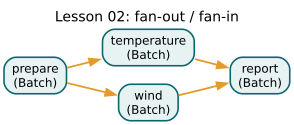

report predecessors: ['temperature', 'wind']


In [6]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-02-") as scratch:
    wf = workflow("Meteorology02", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    temperature = DagonTask(
        TaskType.BATCH,
        "temperature",
        "mkdir -p outputs; printf temperature > outputs/metric.txt",
    )
    wind = DagonTask(
        TaskType.BATCH,
        "wind",
        "mkdir -p outputs; printf wind > outputs/metric.txt",
    )
    report = DagonTask(
        TaskType.BATCH,
        "report",
        "mkdir -p outputs; printf complete > outputs/report.txt",
    )
    for task in (prepare, temperature, wind, report):
        wf.add_task(task)

    wf.make_dependencies()

    # Fan-out: both "temperature" and "wind" depend on "prepare".
    temperature.add_dependency_to(prepare)
    wind.add_dependency_to(prepare)
    # Fan-in: "report" waits for both "temperature" and "wind" to finish.
    report.add_dependency_to(temperature)
    report.add_dependency_to(wind)

    display(draw_workflow(wf, "Lesson 02: fan-out / fan-in"))

    wf.Validate_WF()
    assert {task.name for task in report.prevs} == {"temperature", "wind"}
    wf.run()
    assert Path(report.working_dir, "outputs/report.txt").read_text() == "complete"
    print("report predecessors:", sorted(task.name for task in report.prevs))


## Lesson 3: Scratch Directories, Launchers, and Logs

`task.working_dir` is the actual directory DAGon* used for this run -- read it from
the task object instead of reconstructing it yourself. Alongside `outputs` (Lesson 1),
DAGon* keeps its own bookkeeping (launcher script, exit status, logs) in a `.dagon`
directory. `consume` also demonstrates the `workflow://` staging URI from Lesson 4:
its command reads `workflow:///prepare/outputs/observations.csv` directly.


10


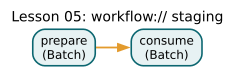

task directory: /tmp/dagon-tutorial-05-zo0o4w31/1790635754024-prepare
.dagon files: ['context.sh', 'launcher.sh', 'ssh_key', 'ssh_key.pub', 'stdout.txt']
consume directory: /tmp/dagon-tutorial-05-zo0o4w31/1790635756465-consume


In [7]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-05-") as scratch:
    wf = workflow("Meteorology05", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    consume_command = (
        "mkdir -p outputs; "
        "cat workflow:///prepare/outputs/observations.csv > outputs/echo.csv"
    )
    consume = DagonTask(TaskType.BATCH, "consume", consume_command)
    wf.add_task(prepare)
    wf.add_task(consume)
    wf.make_dependencies()
    display(draw_workflow(wf, "Lesson 05: workflow:// staging"))
    wf.run()

    meta = Path(prepare.working_dir, ".dagon")
    names = sorted(path.name for path in meta.iterdir())
    assert Path(prepare.working_dir, "outputs/observations.csv").is_file()
    assert names
    print("task directory:", prepare.working_dir)
    print(".dagon files:", names)

    assert Path(consume.working_dir, "outputs/echo.csv").is_file()
    print("consume directory:", consume.working_dir)


## Lesson 4: Workflow Data Dependencies

`workflow:///prepare/outputs/observations.csv` is a DAGon* staging URI:
`<task name>/<path inside that task's outputs>`. DAGon* rewrites it to a real staged
path before the command runs, and *also* uses it to infer that `mean` depends on
`prepare` -- unlike Lesson 2, there is no explicit `add_dependency_to()` call here.


10
logical command: mkdir -p outputs; awk -F, 'NR>1{s+=$3;n++}END{print s/n}' workflow:///prepare/outputs/observations.csv > outputs/mean.txt


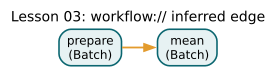

staged mean: 13 in /tmp/dagon-tutorial-03-icqak9i0/1790635761406-mean


In [8]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-03-") as scratch:
    wf = workflow("Meteorology03", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    command = (
        "mkdir -p outputs; "
        "awk -F, 'NR>1{s+=$3;n++}END{print s/n}' "
        "workflow:///prepare/outputs/observations.csv "
        "> outputs/mean.txt"
    )
    mean = DagonTask(TaskType.BATCH, "mean", command)
    wf.add_task(prepare)
    wf.add_task(mean)
    print("logical command:", mean.command)
    wf.make_dependencies()
    assert [task.name for task in mean.prevs] == ["prepare"]
    display(draw_workflow(wf, "Lesson 03: workflow:// inferred edge"))
    wf.run()
    result = Path(mean.working_dir, "outputs/mean.txt").read_text().strip()
    assert result == "13"
    print("staged mean:", result, "in", mean.working_dir)


## Lesson 5: Validate and Fix Cycles

`Validate_WF()` raises instead of silently accepting a graph that could never finish
running. This cell deliberately wires a cycle (`prepare -> analyse -> report ->
prepare`), confirms it is rejected, then repairs it by removing just the back-edge
that closed the loop.


10


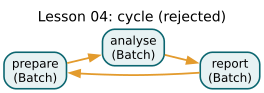

rejected: A cycle has been found involving task prepare


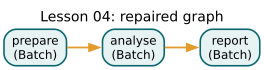

repaired graph validates


In [9]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-04-") as scratch:
    wf = workflow("Meteorology04", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", "true")
    analyse = DagonTask(TaskType.BATCH, "analyse", "true")
    report = DagonTask(TaskType.BATCH, "report", "true")
    for task in (prepare, analyse, report):
        wf.add_task(task)

    analyse.add_dependency_to(prepare)
    report.add_dependency_to(analyse)
    prepare.add_dependency_to(report)

    display(draw_workflow(wf, "Lesson 04: cycle (rejected)"))

    try:
        wf.Validate_WF()
    except Exception as exc:
        assert "cycle" in str(exc).lower()
        print("rejected:", exc)
    else:
        raise AssertionError("cycle was not rejected")

    prepare.prevs.remove(report)
    report.nexts.remove(prepare)
    display(draw_workflow(wf, "Lesson 04: repaired graph"))
    wf.Validate_WF()
    print("repaired graph validates")


## Lesson 6: Data Staging (COPY vs LINK)

`DataMover` controls how a `workflow:///` input (Lesson 4) is materialised in the
consumer's working directory: `COPY` duplicates the producer's file, `LINK` symlinks
to it instead.


In [10]:
def run_staging_mode(mode):
    scratch = tempfile.TemporaryDirectory(prefix="dagon-tutorial-06-")
    wf = workflow("Meteorology06" + mode.name, scratch.name)
    wf.set_data_mover(mode)
    producer = DagonTask(TaskType.BATCH, "prepare", observation_command())
    consumer = DagonTask(
        TaskType.BATCH,
        "consume",
        "cat workflow:///prepare/outputs/observations.csv > consumed.csv",
    )
    wf.add_task(producer)
    wf.add_task(consumer)
    # Time the run itself, not just the staging step, since that's the only
    # granularity DAGon* exposes here -- COPY duplicates bytes, LINK just
    # creates a symlink, so COPY should never be faster than LINK.
    start = time.perf_counter()
    wf.run()
    elapsed = time.perf_counter() - start
    staged = next(
        Path(consumer.working_dir).glob("**/prepare/outputs/observations.csv")
    )
    linked = staged.is_symlink()
    print(f"{mode.name}: is_symlink={linked} elapsed={elapsed:.4f}s {staged}")
    return scratch, linked, elapsed


copy_tmp, copied, copy_elapsed = run_staging_mode(DataMover.COPY)
link_tmp, linked, link_elapsed = run_staging_mode(DataMover.LINK)
assert copied is False and linked is True

print(f"COPY took {copy_elapsed:.4f}s, LINK took {link_elapsed:.4f}s")
copy_tmp.cleanup()
link_tmp.cleanup()


10


COPY: is_symlink=False elapsed=4.7263s /tmp/dagon-tutorial-06-erbe39a0/1790635766288-consume/.dagon/inputs/Meteorology06COPY/prepare/outputs/observations.csv
10


LINK: is_symlink=True elapsed=4.7402s /tmp/dagon-tutorial-06-kevplnxf/1790635771059-consume/.dagon/inputs/Meteorology06LINK/prepare/outputs/observations.csv
COPY took 4.7263s, LINK took 4.7402s


## Lesson 7: Checkpoint and Resume

A second, independent `Workflow` object simulates a fresh process resuming an earlier
run: it gets brand-new task objects, but passing the same checkpoint file to `run()`
tells DAGon* to reuse the completed task's scratch directory instead of re-running its
command.


In [11]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-07-") as scratch:
    checkpoint = Path(scratch, "checkpoint.json")
    wf = workflow("Meteorology07", scratch, checkpoint_file=str(checkpoint))
    # "sleep 2" stands in for an expensive computation: long enough that
    # skipping it on resume is clearly measurable, short enough to keep the
    # lesson quick to run.
    calculate_command = "sleep 2; mkdir -p outputs; printf 13 > outputs/mean.txt"
    task = DagonTask(TaskType.BATCH, "calculate", calculate_command)
    wf.add_task(task)
    start = time.perf_counter()
    wf.run()
    first_elapsed = time.perf_counter() - start
    assert checkpoint.is_file()
    first_dir = task.working_dir

    resumed = workflow("Meteorology07", scratch, checkpoint_file=str(checkpoint))
    second = DagonTask(TaskType.BATCH, "calculate", calculate_command)
    resumed.add_task(second)
    start = time.perf_counter()
    resumed.run(resume_checkpoint_file=str(checkpoint))
    resumed_elapsed = time.perf_counter() - start
    assert Path(second.working_dir, "outputs/mean.txt").read_text() == "13"
    print("checkpoint:", checkpoint, "scratch reused:", first_dir == second.working_dir)
    print(f"first run: {first_elapsed:.2f}s, resumed run: {resumed_elapsed:.2f}s")
    # Resume skips re-executing "sleep 2" entirely -- the saved time tracks
    # the sleep duration, not just measurement noise.
    assert resumed_elapsed < first_elapsed - 1


10


10


checkpoint: /tmp/dagon-tutorial-07-rp8audhu/checkpoint.json scratch reused: True
first run: 4.41s, resumed run: 2.00s


## Lesson 8: Explicit Checkpoint Task

`TaskType.CHECKPOINT` is a different mechanism from Lesson 7's `checkpoint_file=`
workflow-level resume: it is a task in the graph whose "command" is one or more
`workflow:///` references to snapshot. DAGon* stages those files in as usual, then
moves them into the checkpoint task's own working directory -- a stable, named copy
that downstream tasks depend on instead of the original producer. `consume` below
never references `prepare` directly; it goes through `snapshot`.


10


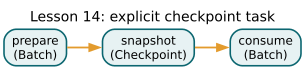

consumed the checkpointed copy: /tmp/dagon-tutorial-14-_rtpyx_0/1790635784708-consume/outputs/echo.csv


In [12]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-14-") as scratch:
    wf = workflow("CheckpointTask14", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    snapshot = DagonTask(
        TaskType.CHECKPOINT, "snapshot", "workflow:///prepare/outputs/observations.csv"
    )
    consume = DagonTask(
        TaskType.BATCH,
        "consume",
        "mkdir -p outputs; "
        "cat workflow:///snapshot/CheckpointTask14/prepare/outputs/observations.csv "
        "> outputs/echo.csv",
    )
    wf.add_task(prepare)
    wf.add_task(snapshot)
    wf.add_task(consume)
    wf.make_dependencies()
    assert [task.name for task in snapshot.prevs] == ["prepare"]
    assert [task.name for task in consume.prevs] == ["snapshot"]
    display(draw_workflow(wf, "Lesson 14: explicit checkpoint task"))
    wf.run()
    result = Path(consume.working_dir, "outputs/echo.csv")
    require_text(result, CSV)
    print("consumed the checkpointed copy:", result)


## Lesson 9: Launch Asynchronously

`launch()` starts the workflow on a background thread and returns immediately, unlike
`run()` (used in every earlier lesson) which blocks until the workflow finishes.
`wait()` blocks -- with a timeout, here 5s -- until the workflow ends. Listeners
observe lifecycle events while it runs.


In [13]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-08-") as scratch:
    wf = workflow("Meteorology08", scratch)
    events = []
    wf.add_listener("on_workflow_start", lambda _: events.append("workflow_start"))
    wf.add_listener("on_workflow_end", lambda _: events.append("workflow_end"))
    wf.add_task(DagonTask(TaskType.BATCH, "analyse", "sleep 0.05; true"))

    start = time.monotonic()
    thread = wf.launch()
    launch_elapsed = time.monotonic() - start
    # If launch() were secretly blocking like run(), this would take at
    # least the task's own 0.05s sleep -- proof it returns immediately.
    assert launch_elapsed < 0.05
    assert thread.is_alive() or events
    assert wf.wait(5)
    assert events == ["workflow_start", "workflow_end"]
    print("events:", events)


10


events: ['workflow_start', 'workflow_end']


## Lesson 10: Docker-Backed Task

`TaskType.DOCKER` runs the same kind of shell command as `BATCH`, but inside a
container started from `image`. DAGon* stages `workflow:///` inputs the same way;
only where the command executes changes. **This lesson needs a real Docker daemon**
on this machine -- unlike every earlier lesson, it is not a mock, and it will fail
if Docker is not installed and running.

Cleanup note: the container runs as root by default, so files it writes into the
bind-mounted scratch directory are root-owned on the host. This cell uses
`shutil.rmtree(..., ignore_errors=True)` instead of `tempfile.TemporaryDirectory()`'s
automatic cleanup for that reason -- a real, common Docker bind-mount gotcha.


In [14]:
scratch = tempfile.mkdtemp(prefix="dagon-tutorial-10-")
try:
    wf = workflow("Meteorology10", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    mean_command = (
        "mkdir -p outputs; "
        "awk -F, 'NR>1{s+=$3;n++}END{print s/n}' "
        "workflow:///prepare/outputs/observations.csv "
        "> outputs/mean.txt"
    )
    mean = DagonTask(TaskType.DOCKER, "mean", mean_command, image="alpine:latest")
    wf.add_task(prepare)
    wf.add_task(mean)
    wf.run()
    result = Path(mean.working_dir, "outputs/mean.txt").read_text().strip()
    assert result == "13"
    print("mean (computed inside alpine:latest):", result)
finally:
    shutil.rmtree(scratch, ignore_errors=True)


10


mean (computed inside alpine:latest): 13


## Lesson 11: Remote Batch Task over SSH

Remote batch is selected by passing SSH parameters (`ip`, `ssh_username`,
`keypath`) to the ordinary `BATCH` `DagonTask` factory -- there is no
separate `TaskType.SSH`. Same `workflow:///` staging as Lesson 4 and
Lesson 10; DAGon* opens the SSH connection, stages inputs onto the remote
host, and reads outputs back over it.

**This lesson needs a reachable SSH host and an authorized key** -- unlike
every earlier lesson, it is not a mock, and unlike Lesson 10 (Docker) it
also needs a one-time `authorized_keys` setup, not just a running daemon.
It targets `127.0.0.1` as a stand-in for a genuinely remote host by
default; see `tutorial/README.md` for the setup this needs and how to
point it at a different host via the `DAGON_TUTORIAL_SSH_*` environment
variables.


In [15]:
remote_host = os.environ.get("DAGON_TUTORIAL_SSH_HOST", "127.0.0.1")
remote_user = os.environ.get("DAGON_TUTORIAL_SSH_USER", os.environ.get("USER", ""))
key_path = os.environ.get(
    "DAGON_TUTORIAL_SSH_KEY", str(Path.home() / ".ssh" / "dagonstar_tutorial_key")
)

with tempfile.TemporaryDirectory(prefix="dagon-tutorial-11-") as scratch:
    wf = workflow("Meteorology11", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    mean_command = (
        "mkdir -p outputs; "
        "awk -F, 'NR>1{s+=$3;n++}END{print s/n}' "
        "workflow:///prepare/outputs/observations.csv "
        "> outputs/mean.txt"
    )
    mean = DagonTask(
        TaskType.BATCH,
        "mean",
        mean_command,
        ip=remote_host,
        ssh_username=remote_user,
        keypath=key_path,
    )
    wf.add_task(prepare)
    wf.add_task(mean)
    wf.run()
    result = Path(mean.working_dir, "outputs/mean.txt").read_text().strip()
    assert result == "13"
    print(f"mean (computed over SSH on {remote_host}):", result)


10


mean (computed over SSH on 127.0.0.1): 13


## Lesson 12: LLM Task

`TaskType.LLM`'s "command" is a chat request body, not a shell string. `input_files`
stages a `workflow:///` file (Lesson 4) and lets `{report}` in the message content
be substituted with its contents before the request is sent.

The chat server below is a deterministic local mock subset of the Chat Completions
protocol -- no real API key or paid provider is involved. This is the same code that
ships as `tutorial/lesson_12_llm_tasks.py` -- see `tutorial/README.md` for why the
filename number differs from this notebook's sequential numbering.


10


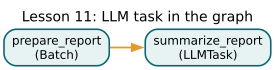

{
  "choices": [
    {
      "message": {
        "content": "Mock summary: Summarize this report: temperature increased by 1.2 C",
        "role": "assistant"
      }
    }
  ]
}



In [16]:
class MockChatHandler(BaseHTTPRequestHandler):
    """A deterministic, local subset of the Chat Completions protocol."""

    def do_POST(self):
        if self.path != "/v1/chat/completions":
            self.send_error(404)
            return
        raw_body = self.rfile.read(int(self.headers["Content-Length"]))
        request = json.loads(raw_body.decode("utf-8"))
        content = request["messages"][-1]["content"]
        message = {"role": "assistant", "content": "Mock summary: " + content}
        response = {"choices": [{"message": message}]}
        payload = json.dumps(response).encode("utf-8")
        self.send_response(200)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(payload)))
        self.end_headers()
        self.wfile.write(payload)

    def log_message(self, _format, *_args):
        pass  # silence the default per-request access log


def run_llm_task_lesson():
    server = ThreadingHTTPServer(("127.0.0.1", 0), MockChatHandler)
    threading.Thread(target=server.serve_forever, daemon=True).start()
    try:
        with tempfile.TemporaryDirectory(prefix="dagon-llm-lesson-") as scratch:
            config = {
                "batch": {"scratch_dir_base": scratch, "run_base": "", "threads": "1"},
                "dagon_service": {"use": "False", "route": "http://localhost:57000"},
                "ftp_pub": {"ip": "localhost", "user": "anonymous", "password": ""},
                "slurm": {"partition": ""},
                "llm.local_mock": {
                    "endpoint": "http://127.0.0.1:%s" % server.server_port,
                    "api_key": "example-key-not-a-secret",
                    "model": "mock-chat",
                },
            }
            wf11 = Workflow("Lesson11", config=config)
            prepare_command = (
                "mkdir -p output; "
                "printf 'temperature increased by 1.2 C' > output/report.txt"
            )
            wf11.add_task(DagonTask(TaskType.BATCH, "prepare_report", prepare_command))
            request_body = {
                "messages": [
                    {"role": "user", "content": "Summarize this report: {report}"}
                ]
            }
            summarize = DagonTask(
                TaskType.LLM,
                "summarize_report",
                request_body,
                provider="local_mock",
                input_files={"report": "workflow:///prepare_report/output/report.txt"},
            )
            wf11.add_task(summarize)
            wf11.make_dependencies()
            display(draw_workflow(wf11, "Lesson 11: LLM task in the graph"))
            wf11.run()
            response_path = Path(summarize.working_dir, "response.json")
            data = json.loads(response_path.read_text(encoding="utf-8"))
            summary = data["choices"][0]["message"]["content"]
            expected = (
                "Mock summary: Summarize this report: temperature increased by 1.2 C"
            )
            assert summary == expected
            print(response_path.read_text(encoding="utf-8"))
            return wf11
    finally:
        server.shutdown()
        server.server_close()


wf11 = run_llm_task_lesson()


## Lesson 13: Web Task

`TaskType.WEB`'s "command" is a request spec, not a shell string: `method`/`url`/
`multipart` describe an HTTP call, and `outputs` maps response parts (body, metadata)
to files DAGon* writes so downstream tasks can read them via `workflow:///` staging
(Lesson 4), like `consume` does below.

The HTTP server below is a deterministic local mock -- no real network or credentials
are involved. This is the same code that ships as `tutorial/lesson_13_web_tasks.py`
-- see `tutorial/README.md` for why the filename number differs from this notebook's
sequential numbering.


10


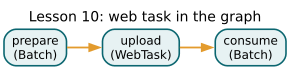

{"received": true}
{
  "auth": {
    "type": "none"
  },
  "body_path": "outputs/reply.json",
  "content_type": "application/json",
  "elapsed_seconds": 0.008740882003621664,
  "headers_path": null,
  "method": "POST",
  "sha256": "88d0044eac54abee64794de14fd02180e3689ed1b3824c9960bbde30bc67349f",
  "status_code": 200,
  "url": "http://127.0.0.1:42871/upload"
}



In [17]:
class EchoHandler(BaseHTTPRequestHandler):
    """Local endpoint used to demonstrate a multipart web task."""

    def do_POST(self):
        body = self.rfile.read(int(self.headers["Content-Length"]))
        received = "sample" in body.decode("utf-8")
        reply = json.dumps({"received": received}).encode("utf-8")
        self.send_response(200)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(reply)))
        self.end_headers()
        self.wfile.write(reply)

    def log_message(self, _format, *_args):
        pass  # silence the default per-request access log


def run_web_task_lesson():
    server = ThreadingHTTPServer(("127.0.0.1", 0), EchoHandler)
    threading.Thread(target=server.serve_forever, daemon=True).start()
    try:
        with tempfile.TemporaryDirectory(prefix="dagon-web-lesson-") as scratch:
            config = {
                "batch": {"scratch_dir_base": scratch, "run_base": "", "threads": "1"},
                "dagon_service": {"use": "False", "route": "http://localhost:57000"},
                "ftp_pub": {"ip": "localhost", "user": "anonymous", "password": ""},
                "slurm": {"partition": ""},
            }
            wf10 = Workflow("Lesson10", config=config)
            wf10.add_task(DagonTask(
                TaskType.BATCH,
                "prepare",
                "mkdir -p output; printf sample > output/data.txt",
            ))
            upload = DagonTask(
                TaskType.WEB,
                "upload",
                {
                    "method": "POST",
                    "url": "http://127.0.0.1:%s/upload" % server.server_port,
                    "multipart": {
                        "dataset": {
                            "file": "workflow:///prepare/output/data.txt",
                            "content_type": "text/plain",
                        }
                    },
                    "expected_status": 200,
                    "outputs": {"body": "reply.json", "metadata": "request.json"},
                },
            )
            wf10.add_task(upload)
            wf10.add_task(DagonTask(
                TaskType.BATCH,
                "consume",
                "cat workflow:///upload/outputs/reply.json",
            ))
            wf10.make_dependencies()
            display(draw_workflow(wf10, "Lesson 10: web task in the graph"))
            wf10.run()
            reply_path = Path(upload.working_dir, "outputs", "reply.json")
            assert json.loads(reply_path.read_text()) == {"received": True}
            result_path = Path(upload.working_dir, ".dagon", "web_result.json")
            web_result = json.loads(result_path.read_text())
            assert web_result["status_code"] == 200
            assert web_result["method"] == "POST"
            print(reply_path.read_text())
            print(result_path.read_text())
            return wf10
    finally:
        server.shutdown()
        server.server_close()


wf10 = run_web_task_lesson()


## Lesson 14: Native Python Task

`TaskType.NATIVE` runs an importable Python function in-process instead of a shell
command: its "command" is a `module:function` path, and `inputs`/`outputs` map
argument names to files DAGon* stages and passes in as paths. See
`tutorial/common/native_functions.py:mean_temperature`, called here as
`mean_temperature(observations=..., result=...)`.


10


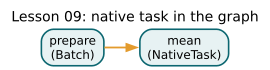

{'mean_temperature_c': 13.0}


In [18]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-09-") as scratch:
    wf = workflow("Meteorology09", scratch)
    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    native = DagonTask(
        TaskType.NATIVE,
        "mean",
        "tutorial.common.native_functions:mean_temperature",
        inputs={"observations": "workflow:///prepare/outputs/observations.csv"},
        outputs={"result": "mean.json"},
    )
    wf.add_task(prepare)
    wf.add_task(native)
    wf.make_dependencies()
    display(draw_workflow(wf, "Lesson 09: native task in the graph"))
    wf.run()
    import json
    result = json.loads(Path(native.working_dir, "outputs/mean.json").read_text())
    assert result == {"mean_temperature_c": 13.0}
    print(result)


## Lesson 15: FAIR by Design

`enable_fair()` turns on lifecycle recording with no change to task execution: it
listens to the same workflow events Lesson 9 uses (`on_task_start`/`on_task_end`,
...) and writes a provenance bundle -- `run.json`, `ro-crate-metadata.json`,
`prov.json`, checksums, a fairness report -- as a byproduct of the graph DAGon*
already built. The dependency edge below is inferred by DAGon* itself (Lesson 4),
not separately declared for FAIR.


10


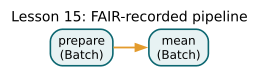

FAIR report written to: /tmp/dagon-tutorial-15-5jsa5sz1/fair-report
fairness status: passed
artifacts recorded: ['outputs/observations.csv', 'outputs/mean.txt']


In [19]:
with tempfile.TemporaryDirectory(prefix="dagon-tutorial-15-") as scratch:
    # output_dir pins the FAIR report next to this run's scratch dir instead
    # of the library's default (nested under a random run id), so the
    # assertions below know exactly where to look.
    fair_dir = Path(scratch, "fair-report")
    wf = workflow("FairDemo15", scratch)
    profile = FairProfile(
        title="Weather observation pipeline",
        description="Deterministic tutorial workflow computing a mean temperature.",
        creators=[Agent(name="DAGonStar Tutorial")],
        license="Apache-2.0",
        keywords=["weather", "tutorial"],
        output_dir=str(fair_dir),
    )
    wf.enable_fair(profile)

    prepare = DagonTask(TaskType.BATCH, "prepare", observation_command())
    prepare.declare_outputs(
        Artifact(
            "outputs/observations.csv",
            name="Observations",
            media_type="text/csv",
            license="Apache-2.0",
        )
    )
    mean_command = (
        "mkdir -p outputs; "
        "awk -F, 'NR>1{s+=$3;n++}END{print s/n}' "
        "workflow:///prepare/outputs/observations.csv "
        "> outputs/mean.txt"
    )
    mean = DagonTask(TaskType.BATCH, "mean", mean_command)
    mean.declare_outputs(
        Artifact(
            "outputs/mean.txt",
            name="Mean temperature",
            media_type="text/plain",
            license="Apache-2.0",
        )
    )
    wf.add_task(prepare)
    wf.add_task(mean)
    wf.make_dependencies()
    display(draw_workflow(wf, "Lesson 15: FAIR-recorded pipeline"))
    wf.run()

    run = json.loads(Path(fair_dir, "run.json").read_text())
    assert run["dependencies"] == [
        {
            "consumer": "mean",
            "path": "outputs/observations.csv",
            "producer": "prepare",
            "type": "workflow-edge",
        }
    ]
    assert len(run["artifacts"]) == 2
    assert all(artifact["checksum"] for artifact in run["artifacts"])

    report = json.loads(Path(fair_dir, "fairness-report.json").read_text())
    assert report["status"] == "passed"
    assert Path(fair_dir, "ro-crate-metadata.json").is_file()

    print("FAIR report written to:", fair_dir)
    print("fairness status:", report["status"])
    print("artifacts recorded:", [a["path"] for a in run["artifacts"]])


## Recap

If every cell above ran without an `AssertionError`, you have exercised the same
scenario taught across the slides: `BATCH` (local and remote over SSH), `DOCKER`, `NATIVE`, `WEB`, `LLM`,
and `CHECKPOINT` task types; explicit and data-oriented dependencies; validation and
cycle repair; both staging modes; checkpoint/resume (both the workflow-level resume
and the explicit `TaskType.CHECKPOINT` task); asynchronous execution; and FAIR
provenance recording.

Continue with:
- `tutorial/README.md` -- how the lesson files relate to each other, and the mapping
  between this notebook's sequential numbers and the `tutorial/lesson_NN_*.py` filenames.
- `slides/DAGonStar_tutorial_slides.md` -- the full talk these lessons accompany.
- `handbook/` -- the complete v2.2 handbook, including topics not covered locally here
  (SSH, Slurm, CWL export, compute-continuum tasks).
